In [ ]:
%pip install mtcnn

In [ ]:

import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

# Install all required packages
!pip install -q protobuf==3.20.3
!pip install -q python-lz4  # Note: package name is python-lz4, not just lz4
!pip install -q mtcnn

print("=" * 70)
print(" INSTALLATION COMPLETE! ".center(70, "="))
print("=" * 70)
print("\n⚠️  IMPORTANT: YOU MUST RESTART THE KERNEL NOW!")
print("\n📌 Steps:")
print("   1. Click 'Session' in the top menu")
print("   2. Click 'Restart Session'")
print("   3. Run all cells from the beginning")
print("\n" + "=" * 70)


In [1]:
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

# Verify installations
print("Verifying installations...")
print("-" * 70)

try:
    import google.protobuf
    print(f"✓ Protobuf: {google.protobuf.__version__}")
except Exception as e:
    print(f"✗ Protobuf error: {e}")

try:
    import lz4
    print(f"✓ LZ4: {lz4.__version__}")
except Exception as e:
    print(f"✗ LZ4 error: {e}")

try:
    from mtcnn import MTCNN
    print(f"✓ MTCNN: Available")
except Exception as e:
    print(f"✗ MTCNN error: {e}")

try:
    import torch
    print(f"✓ PyTorch: {torch.__version__}")
    print(f"✓ CUDA Available: {torch.cuda.is_available()}")
except Exception as e:
    print(f"✗ PyTorch error: {e}")

print("-" * 70)
print("✓ All verifications complete!")

Verifying installations...
----------------------------------------------------------------------
✓ Protobuf: 3.20.3
✓ LZ4: 4.4.5


2025-11-12 15:10:06.426221: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762960206.449139     118 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762960206.456104     118 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✓ MTCNN: Available
✓ PyTorch: 2.6.0+cu124
✓ CUDA Available: True
----------------------------------------------------------------------
✓ All verifications complete!


In [2]:
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

import cv2
import shutil
import glob
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from mtcnn.mtcnn import MTCNN
import json
from datetime import datetime

print("✓ All imports successful!")

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

✓ All imports successful!


In [3]:
class Config:
    # Paths
    SOURCE_FAKE_DIRS = [
        "/kaggle/input/cifake-real-and-ai-generated-synthetic-images/train/FAKE",
        "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/fake/"
    ]
    SOURCE_REAL_DIRS = [
        "/kaggle/input/cifake-real-and-ai-generated-synthetic-images/train/REAL",
        "/kaggle/input/flickrfaceshq-dataset-ffhq/",
        "/kaggle/input/utkface-new/UTKFace/",
        "/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba/",
        "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/real/"
    ]
    
    WORK_DIR = "/kaggle/working"
    FILTERED_DIR = f"{WORK_DIR}/cifake_filtered"
    DATASET_DIR = f"{WORK_DIR}/dataset"
    CHECKPOINT_DIR = f"{WORK_DIR}/checkpoints"
    
    # Model hyperparameters
    MODEL_NAME = 'efficientnet_b3'
    IMG_SIZE = 384
    BATCH_SIZE = 16
    ACCUMULATION_STEPS = 2  # Effective batch size = 32
    
    # Training hyperparameters
    EPOCHS_HEAD = 10
    EPOCHS_FINETUNE = 40
    LR_HEAD = 1e-3
    LR_FINETUNE = 5e-6
    WEIGHT_DECAY = 1e-4
    GRADIENT_CLIP = 1.0
    WARMUP_EPOCHS = 3
    
    # Data parameters
    FILE_LIMIT_PER_CLASS = 50000
    VAL_SPLIT = 0.15
    SEED = 42
    
    # Training parameters
    PATIENCE = 7
    MIN_DELTA = 0.001  # Minimum improvement to reset patience
    LABEL_SMOOTHING = 0.05
    
    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def create_directories():
    """Create necessary directories"""
    dirs = [
        Config.CHECKPOINT_DIR,
        f"{Config.DATASET_DIR}/train/real",
        f"{Config.DATASET_DIR}/train/ai_generated",
        f"{Config.DATASET_DIR}/validation/real",
        f"{Config.DATASET_DIR}/validation/ai_generated"
    ]
    for d in dirs:
        os.makedirs(d, exist_ok=True)

def save_checkpoint(state, filename):
    """Save training checkpoint with metadata"""
    filepath = os.path.join(Config.CHECKPOINT_DIR, filename)
    torch.save(state, filepath)
    print(f"✓ Checkpoint saved: {filename}")

def load_checkpoint(filename):
    """Load training checkpoint"""
    filepath = os.path.join(Config.CHECKPOINT_DIR, filename)
    if os.path.exists(filepath):
        return torch.load(filepath, map_location=Config.DEVICE)
    return None

class Logger:
    """Training logger with file output"""
    def __init__(self, log_file='training.log'):
        self.log_file = os.path.join(Config.WORK_DIR, log_file)
        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'lr': [], 'epoch': []
        }
    
    def log(self, message):
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        log_msg = f"[{timestamp}] {message}"
        print(log_msg)
        with open(self.log_file, 'a') as f:
            f.write(log_msg + '\n')
    
    def update_history(self, epoch, metrics):
        for key, value in metrics.items():
            if key in self.history:
                self.history[key].append(value)
        self.history['epoch'].append(epoch)
    
    def save_history(self):
        history_file = os.path.join(Config.WORK_DIR, 'training_history.json')
        with open(history_file, 'w') as f:
            json.dump(self.history, f, indent=2)

In [5]:
def filter_faces_from_cifake(source_dir, dest_dir, detector):
    """Filter images containing faces using MTCNN"""
    os.makedirs(dest_dir, exist_ok=True)
    image_files = [f for f in os.listdir(source_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    faces_found = 0
    for filename in tqdm(image_files, desc=f"Filtering {os.path.basename(source_dir)}"):
        source_path = os.path.join(source_dir, filename)
        dest_path = os.path.join(dest_dir, filename)
        
        try:
            image = cv2.imread(source_path)
            if image is None:
                continue
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            results = detector.detect_faces(image_rgb)
            
            if results:
                shutil.copy(source_path, dest_path)
                faces_found += 1
        except Exception as e:
            continue
    
    return faces_found

def prepare_cifake_data(logger):
    """Filter CIFAKE dataset for face images"""
    logger.log("=" * 70)
    logger.log("STAGE 1: FILTERING CIFAKE FOR FACES")
    logger.log("=" * 70)
    
    detector = MTCNN()
    
    for source_dir, label in [(Config.SOURCE_FAKE_DIRS[0], "FAKE"), 
                               (Config.SOURCE_REAL_DIRS[0], "REAL")]:
        if not os.path.exists(source_dir):
            logger.log(f"⚠ Skipping missing directory: {source_dir}")
            continue
        
        dest_dir = f"{Config.FILTERED_DIR}/train/{label}"
        faces = filter_faces_from_cifake(source_dir, dest_dir, detector)
        logger.log(f"✓ Found {faces:,} face images in {label}")

def process_and_copy_files(source_paths, dest_train, dest_val, file_limit=None, logger=None):
    """Collect, split, and copy files efficiently"""
    all_files = []
    
    # Collect files from all sources
    for path in source_paths:
        if not os.path.exists(path):
            if logger:
                logger.log(f"⚠ Path not found: {path}")
            continue
        
        for ext in ['*.jpg', '*.png', '*.jpeg', '*.JPG', '*.PNG', '*.JPEG']:
            all_files.extend(glob.glob(os.path.join(path, '**', ext), recursive=True))
    
    all_files = list(set(all_files))  # Remove duplicates
    
    if file_limit and len(all_files) > file_limit:
        all_files = random.sample(all_files, file_limit)
    
    # Split data
    train_files, val_files = train_test_split(
        all_files, 
        test_size=Config.VAL_SPLIT,
        random_state=Config.SEED,
        shuffle=True
    )
    
    # Copy files
    for f in tqdm(train_files, desc="  Copying train"):
        try:
            shutil.copy(f, dest_train)
        except Exception:
            continue
    
    for f in tqdm(val_files, desc="  Copying val"):
        try:
            shutil.copy(f, dest_val)
        except Exception:
            continue
    
    return len(train_files), len(val_files)

def prepare_dataset(logger):
    """Prepare complete dataset with train/val split"""
    logger.log("\n" + "=" * 70)
    logger.log("STAGE 2: PREPARING DATASET")
    logger.log("=" * 70)
    
    # Clean previous dataset
    if os.path.exists(Config.DATASET_DIR):
        shutil.rmtree(Config.DATASET_DIR)
    
    create_directories()
    
    # Update paths to include filtered CIFAKE
    real_paths = [f"{Config.FILTERED_DIR}/train/REAL"] + Config.SOURCE_REAL_DIRS[1:]
    fake_paths = [f"{Config.FILTERED_DIR}/train/FAKE"] + Config.SOURCE_FAKE_DIRS[1:]
    
    # Process real faces
    logger.log("\nProcessing REAL faces...")
    real_train, real_val = process_and_copy_files(
        real_paths,
        f"{Config.DATASET_DIR}/train/real",
        f"{Config.DATASET_DIR}/validation/real",
        file_limit=Config.FILE_LIMIT_PER_CLASS,
        logger=logger
    )
    
    # Process AI faces
    logger.log("\nProcessing AI-GENERATED faces...")
    ai_train, ai_val = process_and_copy_files(
        fake_paths,
        f"{Config.DATASET_DIR}/train/ai_generated",
        f"{Config.DATASET_DIR}/validation/ai_generated",
        file_limit=Config.FILE_LIMIT_PER_CLASS,
        logger=logger
    )
    
    logger.log("\n" + "=" * 70)
    logger.log("DATASET SUMMARY")
    logger.log("=" * 70)
    logger.log(f"Training:   Real={real_train:,} | AI={ai_train:,} | Total={real_train+ai_train:,}")
    logger.log(f"Validation: Real={real_val:,} | AI={ai_val:,} | Total={real_val+ai_val:,}")

In [6]:
class LabelSmoothingBCELoss(nn.Module):
    """BCE loss with label smoothing"""
    def __init__(self, smoothing=0.05):
        super().__init__()
        self.smoothing = smoothing
        self.bce = nn.BCEWithLogitsLoss()
    
    def forward(self, pred, target):
        target = target * (1 - self.smoothing) + 0.5 * self.smoothing
        return self.bce(pred, target)

def get_data_loaders():
    """Create optimized data loaders with augmentation"""
    train_transforms = transforms.Compose([
        transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.RandomGrayscale(p=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.1, scale=(0.02, 0.15))
    ])
    
    val_transforms = transforms.Compose([
        transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    train_dataset = datasets.ImageFolder(f"{Config.DATASET_DIR}/train", transform=train_transforms)
    val_dataset = datasets.ImageFolder(f"{Config.DATASET_DIR}/validation", transform=val_transforms)
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=Config.BATCH_SIZE,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=Config.BATCH_SIZE * 2,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True
    )
    
    return train_loader, val_loader

def calculate_metrics(outputs, labels):
    """Calculate accuracy and predictions"""
    preds = (torch.sigmoid(outputs) > 0.5).float()
    correct = (preds == labels).sum().item()
    accuracy = correct / labels.size(0)
    return accuracy, preds

def validate(model, val_loader, criterion):
    """Validation loop"""
    model.eval()
    val_loss = 0.0
    val_acc = 0.0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(Config.DEVICE, non_blocking=True)
            labels = labels.to(Config.DEVICE, non_blocking=True).float().unsqueeze(1)
            
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            acc, _ = calculate_metrics(outputs, labels)
            val_acc += acc
    
    return val_loss / len(val_loader), val_acc / len(val_loader)

def train_head(model, train_loader, val_loader, criterion, logger):
    """Train only the classification head"""
    logger.log("\n" + "=" * 70)
    logger.log("STAGE 3: TRAINING CLASSIFICATION HEAD")
    logger.log("=" * 70)
    
    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True
    
    optimizer = optim.AdamW(
        model.classifier.parameters(),
        lr=Config.LR_HEAD,
        weight_decay=Config.WEIGHT_DECAY
    )
    
    steps_per_epoch = len(train_loader) // Config.ACCUMULATION_STEPS
    scheduler = OneCycleLR(
        optimizer,
        max_lr=Config.LR_HEAD,
        epochs=Config.EPOCHS_HEAD,
        steps_per_epoch=steps_per_epoch,
        pct_start=0.3
    )
    
    scaler = GradScaler()
    best_val_acc = 0.0
    
    for epoch in range(Config.EPOCHS_HEAD):
        model.train()
        train_loss = 0.0
        train_acc = 0.0
        optimizer.zero_grad()
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{Config.EPOCHS_HEAD}")
        for i, (images, labels) in enumerate(pbar):
            images = images.to(Config.DEVICE, non_blocking=True)
            labels = labels.to(Config.DEVICE, non_blocking=True).float().unsqueeze(1)
            
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels) / Config.ACCUMULATION_STEPS
            
            scaler.scale(loss).backward()
            
            if (i + 1) % Config.ACCUMULATION_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRADIENT_CLIP)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
            
            train_loss += loss.item() * Config.ACCUMULATION_STEPS
            acc, _ = calculate_metrics(outputs, labels)
            train_acc += acc
            
            pbar.set_postfix({'loss': f'{loss.item()*Config.ACCUMULATION_STEPS:.4f}', 'acc': f'{acc:.4f}'})
        
        train_loss /= len(train_loader)
        train_acc /= len(train_loader)
        
        val_loss, val_acc = validate(model, val_loader, criterion)
        
        logger.update_history(epoch + 1, {
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'lr': optimizer.param_groups[0]['lr']
        })
        
        logger.log(f"\nEpoch {epoch+1} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        logger.log(f"         | Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_checkpoint({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_loss': val_loss
            }, 'best_head_model.pth')
            logger.log(f"✓ New best head model saved! (Val Acc: {val_acc*100:.2f}%)")
    
    return model

def train_finetune(model, train_loader, val_loader, criterion, logger, resume_from=None):
    """Fine-tune entire model with checkpoint recovery"""
    logger.log("\n" + "=" * 70)
    logger.log("STAGE 4: FINE-TUNING ENTIRE MODEL")
    logger.log("=" * 70)
    
    # Load best head model if not resuming
    if resume_from is None:
        checkpoint = load_checkpoint('best_head_model.pth')
        if checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
            logger.log("✓ Loaded best head model")
    
    # Unfreeze all parameters
    for param in model.parameters():
        param.requires_grad = True
    
    # Discriminative learning rates
    param_groups = [
        {'params': model.blocks[:4].parameters(), 'lr': Config.LR_FINETUNE * 0.01},
        {'params': model.blocks[4:].parameters(), 'lr': Config.LR_FINETUNE * 0.1},
        {'params': model.classifier.parameters(), 'lr': Config.LR_FINETUNE}
    ]
    
    optimizer = optim.AdamW(param_groups, weight_decay=Config.WEIGHT_DECAY)
    
    steps_per_epoch = len(train_loader) // Config.ACCUMULATION_STEPS
    scheduler = OneCycleLR(
        optimizer,
        max_lr=[Config.LR_FINETUNE * 0.01, Config.LR_FINETUNE * 0.1, Config.LR_FINETUNE],
        epochs=Config.EPOCHS_FINETUNE,
        steps_per_epoch=steps_per_epoch,
        pct_start=0.2
    )
    
    scaler = GradScaler()
    best_val_acc = 0.0
    patience_counter = 0
    start_epoch = 0
    
    # Resume from checkpoint if provided
    if resume_from:
        checkpoint = load_checkpoint(resume_from)
        if checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            start_epoch = checkpoint['epoch']
            best_val_acc = checkpoint.get('best_val_acc', 0.0)
            patience_counter = checkpoint.get('patience_counter', 0)
            logger.log(f"✓ Resumed from epoch {start_epoch} (Best Val Acc: {best_val_acc*100:.2f}%)")
    
    for epoch in range(start_epoch, Config.EPOCHS_FINETUNE):
        model.train()
        train_loss = 0.0
        train_acc = 0.0
        optimizer.zero_grad()
        
        pbar = tqdm(train_loader, desc=f"Epoch {Config.EPOCHS_HEAD + epoch+1}/{Config.EPOCHS_HEAD + Config.EPOCHS_FINETUNE}")
        for i, (images, labels) in enumerate(pbar):
            images = images.to(Config.DEVICE, non_blocking=True)
            labels = labels.to(Config.DEVICE, non_blocking=True).float().unsqueeze(1)
            
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels) / Config.ACCUMULATION_STEPS
            
            scaler.scale(loss).backward()
            
            if (i + 1) % Config.ACCUMULATION_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRADIENT_CLIP)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
            
            train_loss += loss.item() * Config.ACCUMULATION_STEPS
            acc, _ = calculate_metrics(outputs, labels)
            train_acc += acc
            
            pbar.set_postfix({'loss': f'{loss.item()*Config.ACCUMULATION_STEPS:.4f}', 'acc': f'{acc:.4f}'})
        
        train_loss /= len(train_loader)
        train_acc /= len(train_loader)
        
        val_loss, val_acc = validate(model, val_loader, criterion)
        
        logger.update_history(Config.EPOCHS_HEAD + epoch + 1, {
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'lr': optimizer.param_groups[0]['lr']
        })
        
        logger.log(f"\nEpoch {Config.EPOCHS_HEAD + epoch+1} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        logger.log(f"                 | Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")
        
        # Save regular checkpoint
        save_checkpoint({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'best_val_acc': best_val_acc,
            'patience_counter': patience_counter
        }, f'finetune_epoch_{epoch+1}.pth')
        
        # Save best model
        if val_acc > best_val_acc + Config.MIN_DELTA:
            best_val_acc = val_acc
            patience_counter = 0
            save_checkpoint({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_loss': val_loss
            }, 'best_model.pth')
            logger.log(f"✓ New best model saved! (Val Acc: {val_acc*100:.2f}%)")
        else:
            patience_counter += 1
            logger.log(f"No improvement ({patience_counter}/{Config.PATIENCE})")
        
        # Early stopping
        if patience_counter >= Config.PATIENCE:
            logger.log(f"\n⚠ Early stopping triggered after {epoch+1} epochs")
            break
    
    return model

def plot_training_history(logger):
    """Generate training visualization"""
    history = logger.history
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Loss
    axes[0].plot(history['epoch'], history['train_loss'], label='Train', linewidth=2)
    axes[0].plot(history['epoch'], history['val_loss'], label='Val', linewidth=2)
    axes[0].axvline(x=Config.EPOCHS_HEAD, color='r', linestyle='--', label='Fine-tuning')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(history['epoch'], [a*100 for a in history['train_acc']], label='Train', linewidth=2)
    axes[1].plot(history['epoch'], [a*100 for a in history['val_acc']], label='Val', linewidth=2)
    axes[1].axvline(x=Config.EPOCHS_HEAD, color='r', linestyle='--', label='Fine-tuning')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Learning rate
    axes[2].plot(history['epoch'], history['lr'], linewidth=2, color='green')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_title('Learning Rate Schedule')
    axes[2].set_yscale('log')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{Config.WORK_DIR}/training_history.png", dpi=300, bbox_inches='tight')
    logger.log("✓ Training curves saved")

=============== AI FACE DETECTOR - OPTIMIZED TRAINING ================
[2025-11-12 15:10:36] Device: cuda
[2025-11-12 15:10:36] Model: efficientnet_b3
[2025-11-12 15:10:36] Image Size: 384x384
[2025-11-12 15:10:36] Effective Batch Size: 32
[2025-11-12 15:10:36] ======================================================================
[2025-11-12 15:10:36] STAGE 1: FILTERING CIFAKE FOR FACES
[2025-11-12 15:10:36] ======================================================================


I0000 00:00:1762960237.282153     118 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1762960237.282852     118 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Filtering FAKE: 100%|██████████| 50000/50000 [49:54<00:00, 16.70it/s] 


[2025-11-12 16:00:33] ✓ Found 182 face images in FAKE


Filtering REAL: 100%|██████████| 50000/50000 [48:08<00:00, 17.31it/s] 


[2025-11-12 16:48:41] ✓ Found 132 face images in REAL
[2025-11-12 16:48:41] 
[2025-11-12 16:48:41] STAGE 2: PREPARING DATASET
[2025-11-12 16:48:41] ======================================================================
[2025-11-12 16:48:41] 
Processing REAL faces...


...

[2025-11-12 19:07:26] 
Epoch 8 | Train Loss: 0.3275 | Train Acc: 89.64%
[2025-11-12 19:07:26]          | Val Loss:   0.3008 | Val Acc:   91.30%
✓ Checkpoint saved: best_head_model.pth
[2025-11-12 19:07:26] ✓ New best head model saved! (Val Acc: 91.30%)


Epoch 9/10: 100%|██████████| 5313/5313 [12:40<00:00,  6.99it/s, loss=0.3429, acc=0.7500]


[2025-11-12 19:21:10] 
Epoch 9 | Train Loss: 0.3217 | Train Acc: 89.92%
[2025-11-12 19:21:10]          | Val Loss:   0.2981 | Val Acc:   91.44%
✓ Checkpoint saved: best_head_model.pth
[2025-11-12 19:21:10] ✓ New best head model saved! (Val Acc: 91.44%)


Epoch 10/10: 100%|██████████| 5313/5313 [12:40<00:00,  6.99it/s, loss=0.3794, acc=0.8750]


[2025-11-12 19:34:53] 
Epoch 10 | Train Loss: 0.3228 | Train Acc: 89.91%
[2025-11-12 19:34:53]          | Val Loss:   0.3191 | Val Acc:   90.24%
[2025-11-12 19:34:55] ✓ Training curves saved
[2025-11-12 19:34:55] 
[2025-11-12 19:34:55] ========================= TRAINING COMPLETE! =========================
[2025-11-12 19:34:55] ======================================================================


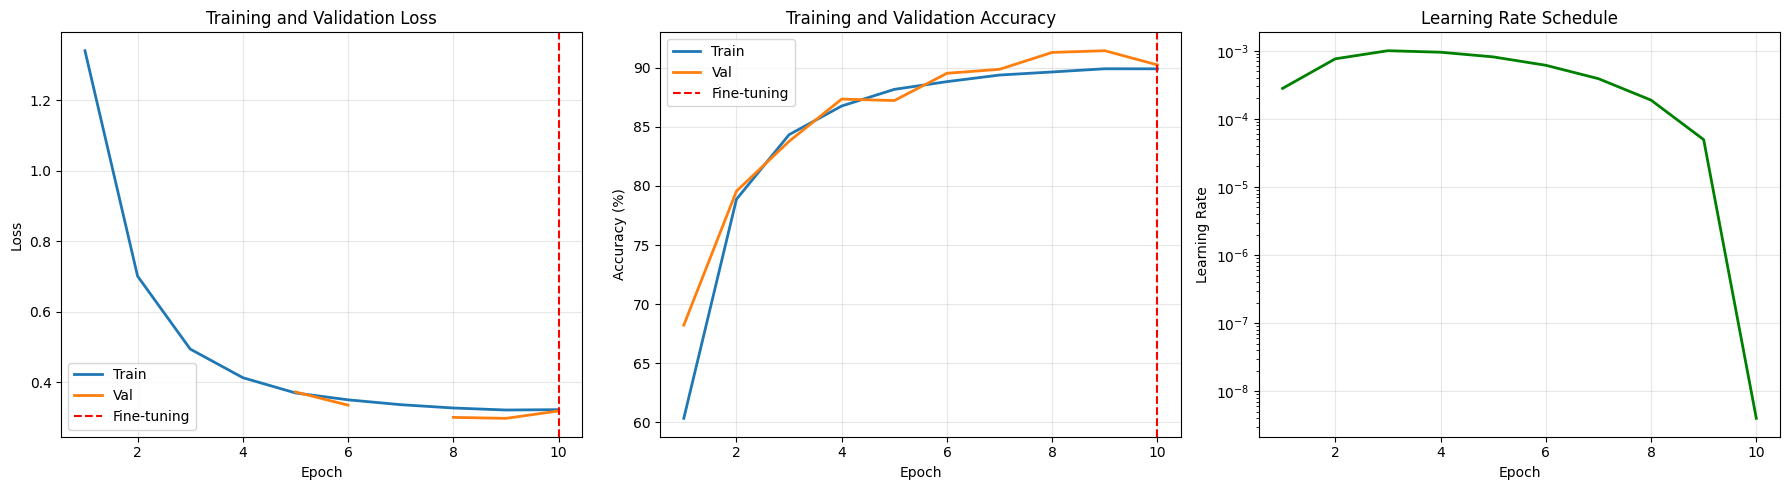

In [7]:
def main():
    """Main training pipeline with checkpoint recovery"""
    print("=" * 70)
    print(" AI FACE DETECTOR - OPTIMIZED TRAINING ".center(70, "="))
    print("=" * 70)
    
    set_seed(Config.SEED)
    create_directories()
    logger = Logger()
    
    logger.log(f"Device: {Config.DEVICE}")
    logger.log(f"Model: {Config.MODEL_NAME}")
    logger.log(f"Image Size: {Config.IMG_SIZE}x{Config.IMG_SIZE}")
    logger.log(f"Effective Batch Size: {Config.BATCH_SIZE * Config.ACCUMULATION_STEPS}")
    
    # Data preparation
    prepare_cifake_data(logger)
    prepare_dataset(logger)
    
    # Create data loaders
    train_loader, val_loader = get_data_loaders()
    logger.log(f"\n✓ Train batches: {len(train_loader)}")
    logger.log(f"✓ Val batches: {len(val_loader)}")
    
    # Create model
    model = timm.create_model(Config.MODEL_NAME, pretrained=True, num_classes=1)
    model = model.to(Config.DEVICE)
    criterion = LabelSmoothingBCELoss(smoothing=Config.LABEL_SMOOTHING)
    
    # Stage 1: Train head
    model = train_head(model, train_loader, val_loader, criterion, logger)
    
    # Stage 2: Fine-tune (with checkpoint recovery option)
    # To resume from a checkpoint, pass: resume_from='finetune_epoch_X.pth'
   # model = train_finetune(model, train_loader, val_loader, criterion, logger, resume_from=None)
    
    # Save final model
    checkpoint = load_checkpoint('best_model.pth')
    if checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        torch.save(model.state_dict(), f"{Config.WORK_DIR}/ai_face_detector_final.pth")
        logger.log(f"\n✓ Final model saved (Best Val Acc: {checkpoint['val_acc']*100:.2f}%)")
    
    # Save history and plot
    logger.save_history()
    plot_training_history(logger)
    
    logger.log("\n" + "=" * 70)
    logger.log(" TRAINING COMPLETE! ".center(70, "="))
    logger.log("=" * 70)

if __name__ == "__main__":
    main()


In [12]:
import timm
import torch

# Recreate the model architecture
model = timm.create_model(Config.MODEL_NAME, pretrained=False, num_classes=1)

# Load the best head model weights
checkpoint = load_checkpoint('best_head_model.pth')
if checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Save as final model
    final_path = f"{Config.WORK_DIR}/ai_face_detector_final.pth"
    torch.save(model.state_dict(), final_path)
    
    print("=" * 70)
    print(" MODEL SAVED SUCCESSFULLY ".center(70, "="))
    print("=" * 70)
    print(f"✓ Model: {Config.MODEL_NAME}")
    print(f"✓ Validation Accuracy: {checkpoint['val_acc']*100:.2f}%")
    print(f"✓ Validation Loss: {checkpoint['val_loss']:.4f}")
    print(f"✓ Saved to: {final_path}")
    print("=" * 70)
else:
    print("❌ Could not find best_head_model.pth")

====================== MODEL SAVED SUCCESSFULLY ======================
✓ Model: efficientnet_b3
✓ Validation Accuracy: 91.44%
✓ Validation Loss: 0.2981
✓ Saved to: /kaggle/working/ai_face_detector_final.pth


In [5]:
def evaluate_model(model_path='ai_face_detector_final.pth', test_dir=None):
    """
    Comprehensive model evaluation with metrics and visualizations
    
    Args:
        model_path: Path to the trained model weights
        test_dir: Path to test dataset (if None, uses validation set)
    """
    print("\n" + "=" * 70)
    print(" MODEL EVALUATION ".center(70, "="))
    print("=" * 70)
    
    # Setup
    if test_dir is None:
        test_dir = f"{Config.DATASET_DIR}/validation"
        print(f"Using validation set: {test_dir}")
    else:
        print(f"Using test set: {test_dir}")
    
    # Load model
    model = timm.create_model(Config.MODEL_NAME, pretrained=False, num_classes=1)
    
    model_full_path = os.path.join(Config.WORK_DIR, model_path)
    if os.path.exists(model_full_path):
        model.load_state_dict(torch.load(model_full_path, map_location=Config.DEVICE))
        print(f"✓ Model loaded from: {model_path}")
    else:
        print(f"⚠ Model file not found: {model_full_path}")
        return
    
    model = model.to(Config.DEVICE)
    model.eval()
    
    # Create test data loader
    test_transforms = transforms.Compose([
        transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)
    test_loader = DataLoader(
        test_dataset,
        batch_size=Config.BATCH_SIZE * 2,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    
    print(f"✓ Test samples: {len(test_dataset):,}")
    print(f"✓ Test batches: {len(test_loader)}")
    
    # Get predictions
    all_preds = []
    all_labels = []
    all_probs = []
    
    print("\nRunning inference...")
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images = images.to(Config.DEVICE)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            
            all_probs.extend(probs.flatten())
            all_preds.extend(preds.flatten())
            all_labels.extend(labels.numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    
    print("\n" + "=" * 70)
    print(" RESULTS ".center(70, "="))
    print("=" * 70)
    print(f"Overall Accuracy: {accuracy * 100:.2f}%")
    print("\nDetailed Classification Report:")
    print("-" * 70)
    
    class_names = test_dataset.classes  # ['ai_generated', 'real']
    print(classification_report(
        all_labels, 
        all_preds, 
        target_names=class_names,
        digits=4
    ))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Count'}
    )
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(f'Confusion Matrix\nAccuracy: {accuracy*100:.2f}%', fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{Config.WORK_DIR}/confusion_matrix.png", dpi=300, bbox_inches='tight')
    print(f"\n✓ Confusion matrix saved to: confusion_matrix.png")
    
    # ROC Curve and AUC
    from sklearn.metrics import roc_curve, auc, roc_auc_score
    
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{Config.WORK_DIR}/roc_curve.png", dpi=300, bbox_inches='tight')
    print(f"✓ ROC curve saved to: roc_curve.png")
    print(f"\nAUC Score: {roc_auc:.4f}")
    
    # Precision-Recall Curve
    from sklearn.metrics import precision_recall_curve, average_precision_score
    
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    avg_precision = average_precision_score(all_labels, all_probs)
    
    plt.figure(figsize=(10, 8))
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {avg_precision:.4f})')
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curve', fontsize=14)
    plt.legend(loc="lower left", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{Config.WORK_DIR}/precision_recall_curve.png", dpi=300, bbox_inches='tight')
    print(f"✓ Precision-Recall curve saved to: precision_recall_curve.png")
    print(f"Average Precision: {avg_precision:.4f}")
    
    # Prediction distribution
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Distribution by class
    for label, class_name in enumerate(class_names):
        mask = all_labels == label
        axes[0].hist(all_probs[mask], bins=50, alpha=0.6, label=class_name, edgecolor='black')
    axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold')
    axes[0].set_xlabel('Predicted Probability', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].set_title('Prediction Distribution by True Class', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Confidence distribution
    confidence = np.maximum(all_probs, 1 - all_probs)
    correct = (all_preds == all_labels)
    
    axes[1].hist(confidence[correct], bins=50, alpha=0.6, label='Correct', color='green', edgecolor='black')
    axes[1].hist(confidence[~correct], bins=50, alpha=0.6, label='Incorrect', color='red', edgecolor='black')
    axes[1].set_xlabel('Prediction Confidence', fontsize=11)
    axes[1].set_ylabel('Frequency', fontsize=11)
    axes[1].set_title('Confidence Distribution (Correct vs Incorrect)', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{Config.WORK_DIR}/prediction_distributions.png", dpi=300, bbox_inches='tight')
    print(f"✓ Prediction distributions saved to: prediction_distributions.png")
    
    # Per-class accuracy
    print("\n" + "=" * 70)
    print(" PER-CLASS PERFORMANCE ".center(70, "="))
    print("=" * 70)
    
    for label, class_name in enumerate(class_names):
        mask = all_labels == label
        class_acc = accuracy_score(all_labels[mask], all_preds[mask])
        class_count = mask.sum()
        print(f"{class_name:15s}: {class_acc*100:6.2f}% ({class_count:,} samples)")
    
    # Error analysis
    print("\n" + "=" * 70)
    print(" ERROR ANALYSIS ".center(70, "="))
    print("=" * 70)
    
    # False positives and false negatives
    fp_mask = (all_labels == 0) & (all_preds == 1)  # AI predicted as Real
    fn_mask = (all_labels == 1) & (all_preds == 0)  # Real predicted as AI
    
    fp_count = fp_mask.sum()
    fn_count = fn_mask.sum()
    
    print(f"False Positives (AI → Real): {fp_count:,} ({fp_count/len(all_labels)*100:.2f}%)")
    print(f"False Negatives (Real → AI): {fn_count:,} ({fn_count/len(all_labels)*100:.2f}%)")
    
    # Low confidence predictions
    low_conf_threshold = 0.6
    low_conf_mask = confidence < low_conf_threshold
    low_conf_count = low_conf_mask.sum()
    low_conf_acc = accuracy_score(all_labels[low_conf_mask], all_preds[low_conf_mask])
    
    print(f"\nLow Confidence Predictions (< {low_conf_threshold}):")
    print(f"  Count: {low_conf_count:,} ({low_conf_count/len(all_labels)*100:.2f}%)")
    print(f"  Accuracy: {low_conf_acc*100:.2f}%")
    
    # High confidence predictions
    high_conf_threshold = 0.9
    high_conf_mask = confidence > high_conf_threshold
    high_conf_count = high_conf_mask.sum()
    high_conf_acc = accuracy_score(all_labels[high_conf_mask], all_preds[high_conf_mask])
    
    print(f"\nHigh Confidence Predictions (> {high_conf_threshold}):")
    print(f"  Count: {high_conf_count:,} ({high_conf_count/len(all_labels)*100:.2f}%)")
    print(f"  Accuracy: {high_conf_acc*100:.2f}%")
    
    # Save evaluation results
    results = {
        'accuracy': float(accuracy),
        'auc': float(roc_auc),
        'average_precision': float(avg_precision),
        'false_positives': int(fp_count),
        'false_negatives': int(fn_count),
        'per_class_accuracy': {
            class_name: float(accuracy_score(all_labels[all_labels == label], 
                                            all_preds[all_labels == label]))
            for label, class_name in enumerate(class_names)
        },
        'total_samples': len(all_labels)
    }
    
    results_file = os.path.join(Config.WORK_DIR, 'evaluation_results.json')
    with open(results_file, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"\n✓ Evaluation results saved to: evaluation_results.json")
    
    print("\n" + "=" * 70)
    print(" EVALUATION COMPLETE! ".center(70, "="))
    print("=" * 70)
    
    return results

In [3]:
def predict_single_image(image_path, model_path='ai_face_detector_final.pth'):
    """
    Predict whether a single image contains an AI-generated face
    
    Args:
        image_path: Path to the image file
        model_path: Path to the trained model weights
    
    Returns:
        dict: Prediction results with probability and label
    """
    # Load model
    model = timm.create_model(Config.MODEL_NAME, pretrained=False, num_classes=1)
    model_full_path = os.path.join(Config.WORK_DIR, model_path)
    model.load_state_dict(torch.load(model_full_path, map_location=Config.DEVICE))
    model = model.to(Config.DEVICE)
    model.eval()
    
    # Prepare image
    transform = transforms.Compose([
        transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    from PIL import Image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(Config.DEVICE)
    
    # Predict
    with torch.no_grad():
        output = model(image_tensor)
        probability = torch.sigmoid(output).item()
    
    prediction = "Real" if probability > 0.5 else "AI-Generated"
    confidence = probability if probability > 0.5 else (1 - probability)
    
    result = {
        'prediction': prediction,
        'confidence': confidence,
        'probability_real': probability,
        'probability_ai': 1 - probability
    }
    
    print(f"\nPrediction: {prediction}")
    print(f"Confidence: {confidence*100:.2f}%")
    print(f"P(Real): {probability*100:.2f}%")
    print(f"P(AI): {(1-probability)*100:.2f}%")
    
    return result

In [4]:
def predict_batch(image_dir, model_path='ai_face_detector_final.pth', output_csv='predictions.csv'):
    """
    Run inference on a directory of images and save results to CSV
    
    Args:
        image_dir: Directory containing images
        model_path: Path to the trained model weights
        output_csv: Output CSV filename
    """
    import pandas as pd
    from pathlib import Path
    
    print(f"\n{'='*70}")
    print(f" BATCH INFERENCE ".center(70, '='))
    print(f"{'='*70}")
    
    # Load model
    model = timm.create_model(Config.MODEL_NAME, pretrained=False, num_classes=1)
    model_full_path = os.path.join(Config.WORK_DIR, model_path)
    model.load_state_dict(torch.load(model_full_path, map_location=Config.DEVICE))
    model = model.to(Config.DEVICE)
    model.eval()
    
    # Prepare transform
    transform = transforms.Compose([
        transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Get all images
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
    image_paths = []
    for ext in image_extensions:
        image_paths.extend(Path(image_dir).glob(f"**/{ext}"))
    
    print(f"Found {len(image_paths)} images")
    
    # Run predictions
    results = []
    from PIL import Image
    
    for img_path in tqdm(image_paths, desc="Processing images"):
        try:
            image = Image.open(img_path).convert('RGB')
            image_tensor = transform(image).unsqueeze(0).to(Config.DEVICE)
            
            with torch.no_grad():
                output = model(image_tensor)
                probability = torch.sigmoid(output).item()
            
            prediction = "Real" if probability > 0.5 else "AI-Generated"
            confidence = probability if probability > 0.5 else (1 - probability)
            
            results.append({
                'filename': img_path.name,
                'path': str(img_path),
                'prediction': prediction,
                'confidence': confidence,
                'probability_real': probability,
                'probability_ai': 1 - probability
            })
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue
    
    # Save to CSV
    df = pd.DataFrame(results)
    output_path = os.path.join(Config.WORK_DIR, output_csv)
    df.to_csv(output_path, index=False)
    
    print(f"\n✓ Results saved to: {output_csv}")
    print(f"\nSummary:")
    print(f"  Total processed: {len(results)}")
    print(f"  Predicted as Real: {(df['prediction'] == 'Real').sum()}")
    print(f"  Predicted as AI-Generated: {(df['prediction'] == 'AI-Generated').sum()}")
    print(f"  Average confidence: {df['confidence'].mean()*100:.2f}%")
    
    return df